C:\Users\natej\anaconda3\Lib\site-packages\sklearn\base.py:432: UserWarning: X has feature names, but DecisionTreeClassifier was fitted without feature names
  warnings.warn(


              precision    recall  f1-score   support

 non-healing       0.20      0.67      0.31         3
     healing       0.80      0.33      0.47        12

   micro avg       0.40      0.40      0.40        15
   macro avg       0.50      0.50      0.39        15
weighted avg       0.68      0.40      0.44        15
 samples avg       0.40      0.40      0.40        15



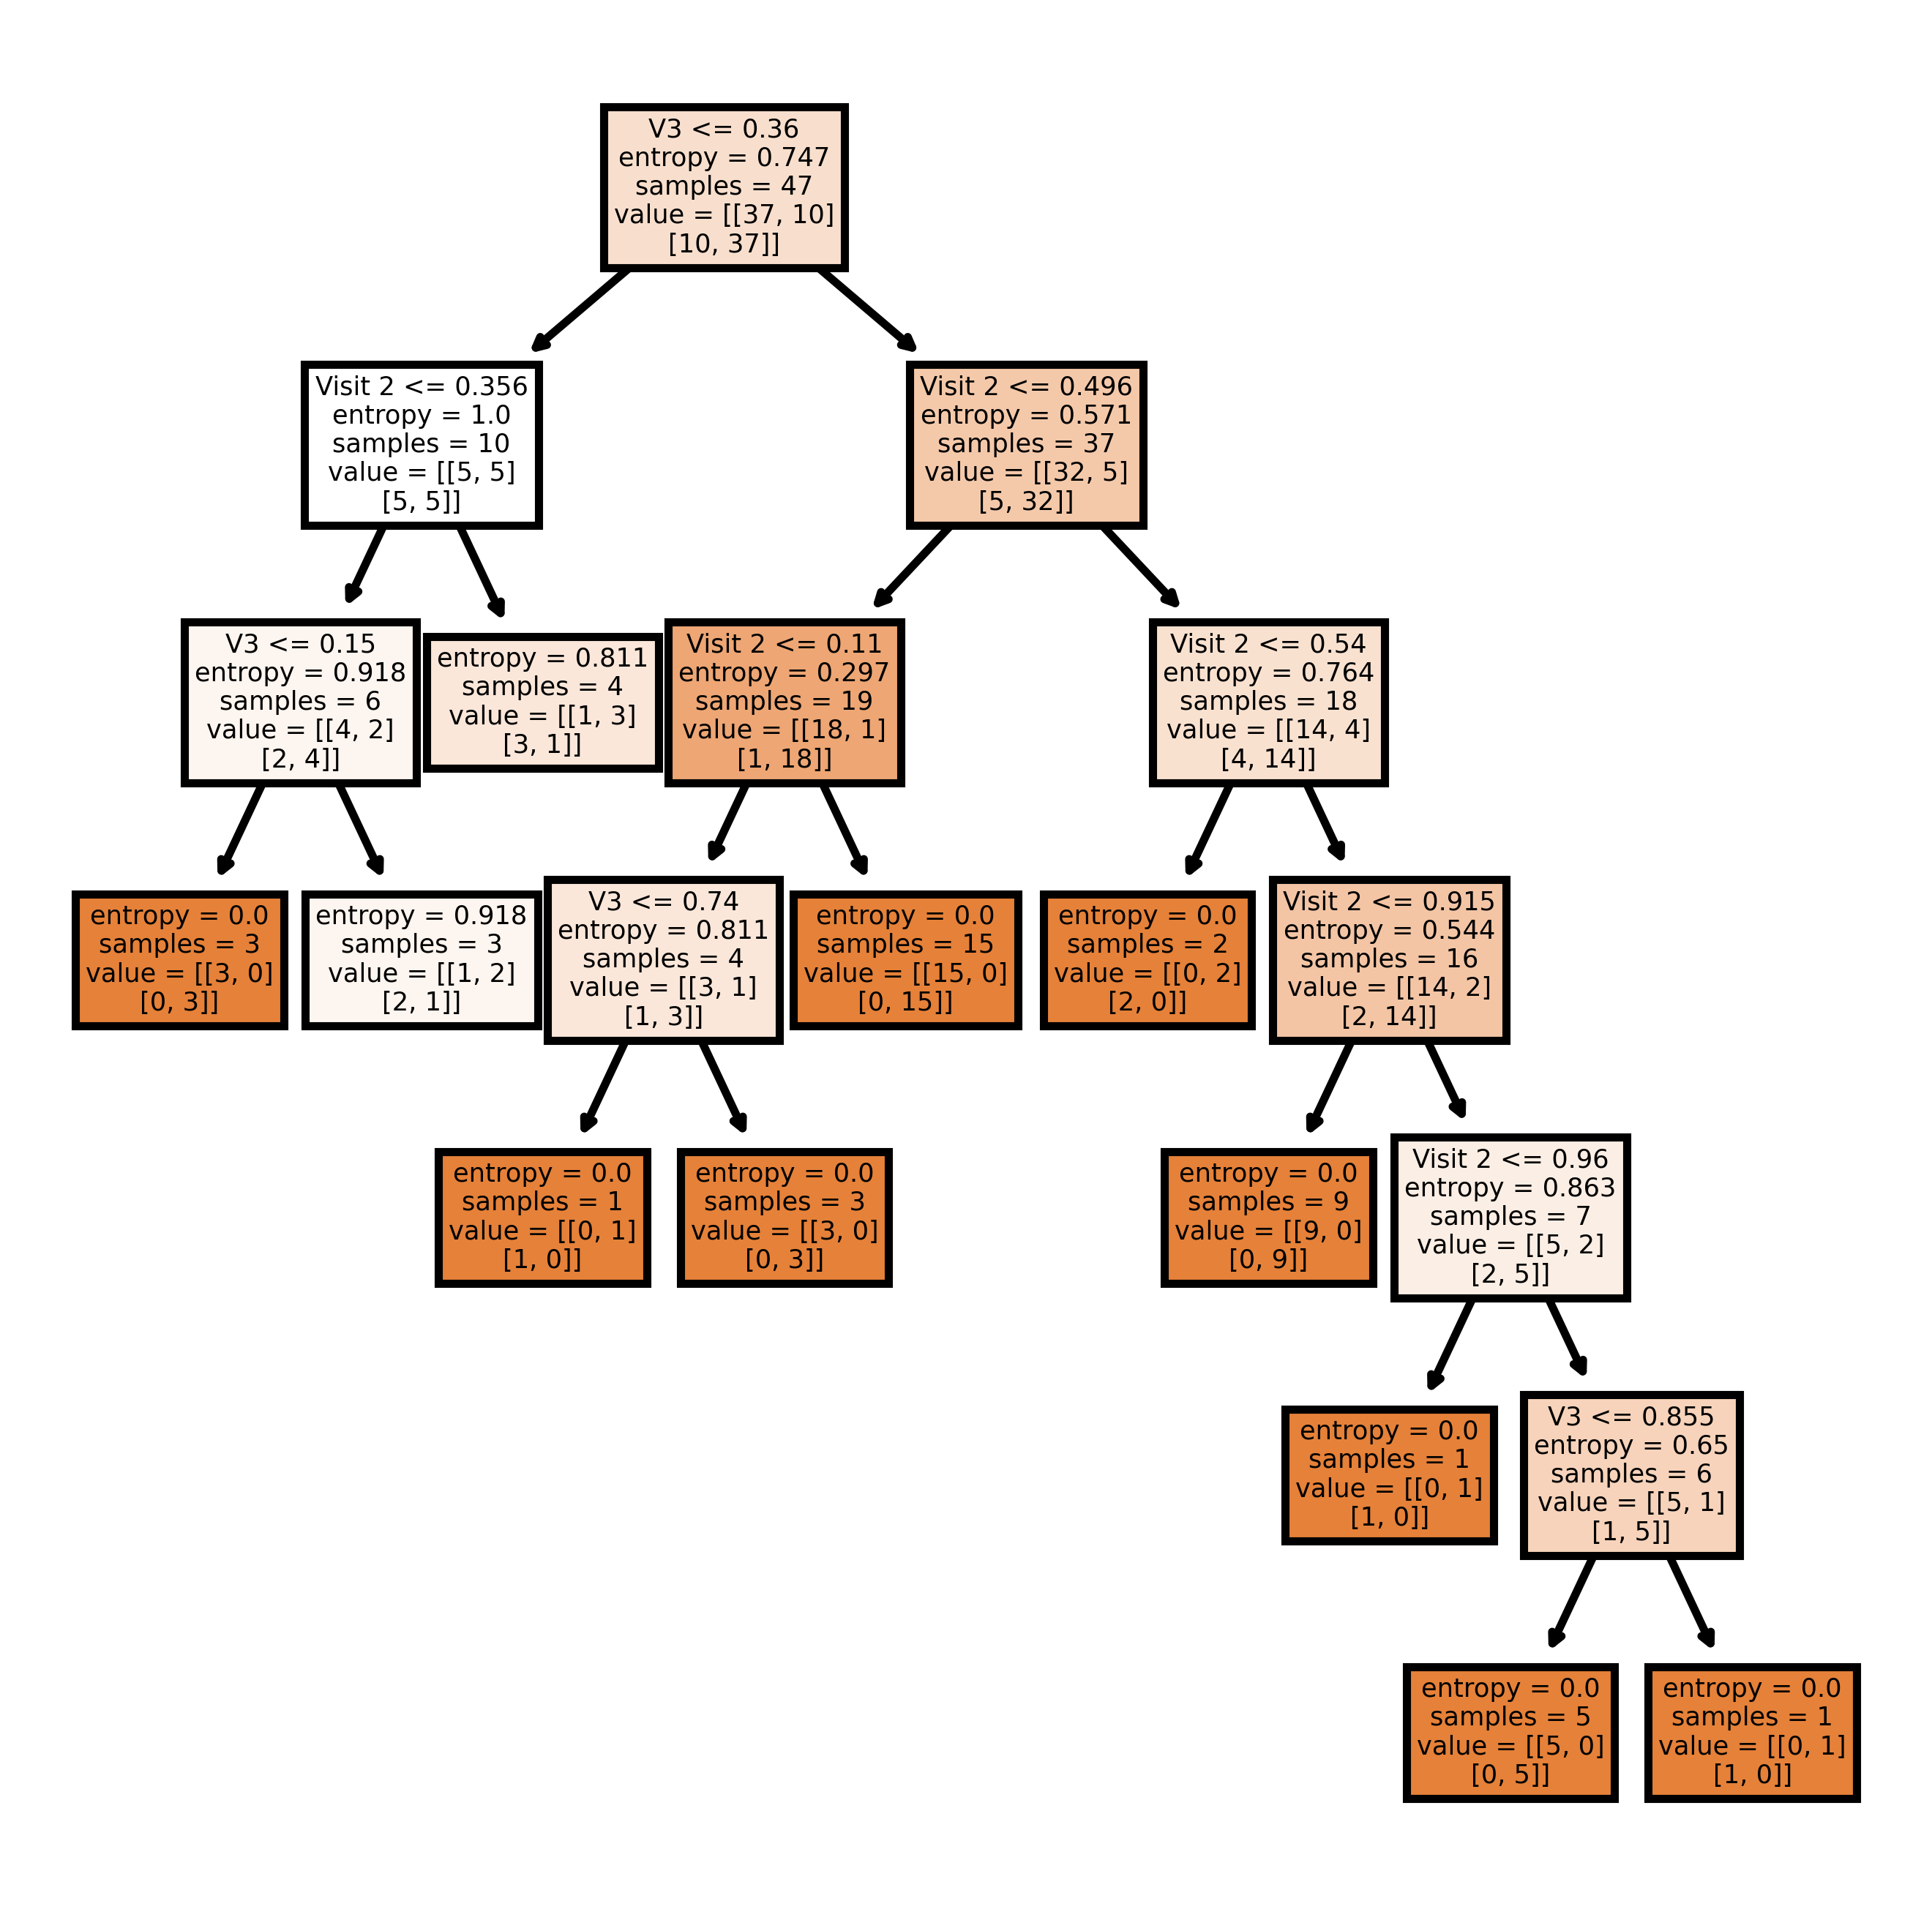

Accuracy: 40.0 %


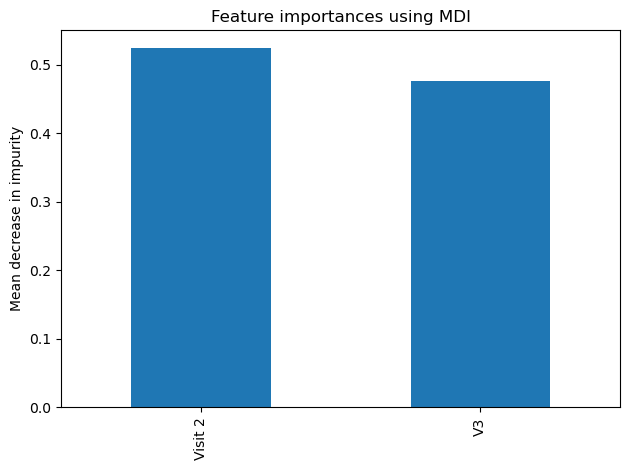

In [1]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn import tree
import matplotlib.pyplot as plt
import matplotlib
import numpy as np
import pandas as pd
import random
from tensorflow.keras.utils import to_categorical
from sklearn.tree import DecisionTreeClassifier
from sklearn.impute import SimpleImputer


Treatment=pd.read_csv("../dissertation/CD105.csv")
Treatment_test=pd.read_csv("../dissertation/CD105 test.csv")
X_train=Treatment.iloc[:,1:]
df_y=Treatment.iloc[:,0]

imp = SimpleImputer(missing_values=np.nan, strategy='mean')
imp.fit(X_train)
X_train=imp.transform(X_train)

X_test=Treatment_test.iloc[:,1:]
df_y_test=Treatment_test.iloc[:,0]


y_train = to_categorical(df_y)
y_test = to_categorical(df_y_test)







names=["Visit 2","V3"]



clf=DecisionTreeClassifier(max_depth=None,
                           # class_weight="balanced",
                               criterion="entropy",
                              ccp_alpha=0.04,
                  
    )

clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)
y_pred = (y_pred > 0.5) 

print(classification_report(y_test,y_pred,output_dict=False,target_names=["non-healing","healing"]))

fig, axes = plt.subplots(nrows = 1,ncols = 1,figsize = (4,4), dpi=800)

tree.plot_tree(clf, filled = True,feature_names=names);
plt.savefig('Tree', dpi=1200)
plt.show()

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", (accuracy*100),"%")

importances = clf.feature_importances_
forest_importances = pd.Series(importances, index=names)
fig, ax = plt.subplots()
forest_importances.plot.bar( ax=ax)
ax.set_title("Feature importances using MDI")
ax.set_ylabel("Mean decrease in impurity")
fig.tight_layout()
plt.show()
target = 'key'
class_names=["non-healing","healing"]

from supertree import SuperTree
st = SuperTree(
    clf, 
    X_train, 
    df_y, 
    names, 
    class_names
)
# Visualize the tree
st.show_tree()